# CO2 & Greenhouse Gas Emissions — Exploratory Analysis
### Data: Our World in Data (`owid-co2-data.csv`)
**Coverage:** ~200 countries/regions, 1750–present, 79 variables

**Sections**
1. Load & orient
2. Global totals over time
3. Top emitters
4. Emissions by source (coal / oil / gas / cement / LUC)
5. Per-capita & intensity
6. CO₂ vs GDP
7. Cumulative responsibility
8. Temperature attribution

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

df = pd.read_csv("../data/owid-co2-data.csv")
print(f"Shape: {df.shape}")
print(f"Years:  {df['year'].min()} – {df['year'].max()}")
print(f"Countries/regions: {df['country'].nunique()}")

Shape: (50411, 79)
Years:  1750 – 2024
Countries/regions: 254


## 1. Load & orient

In [17]:
df.head(3)

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


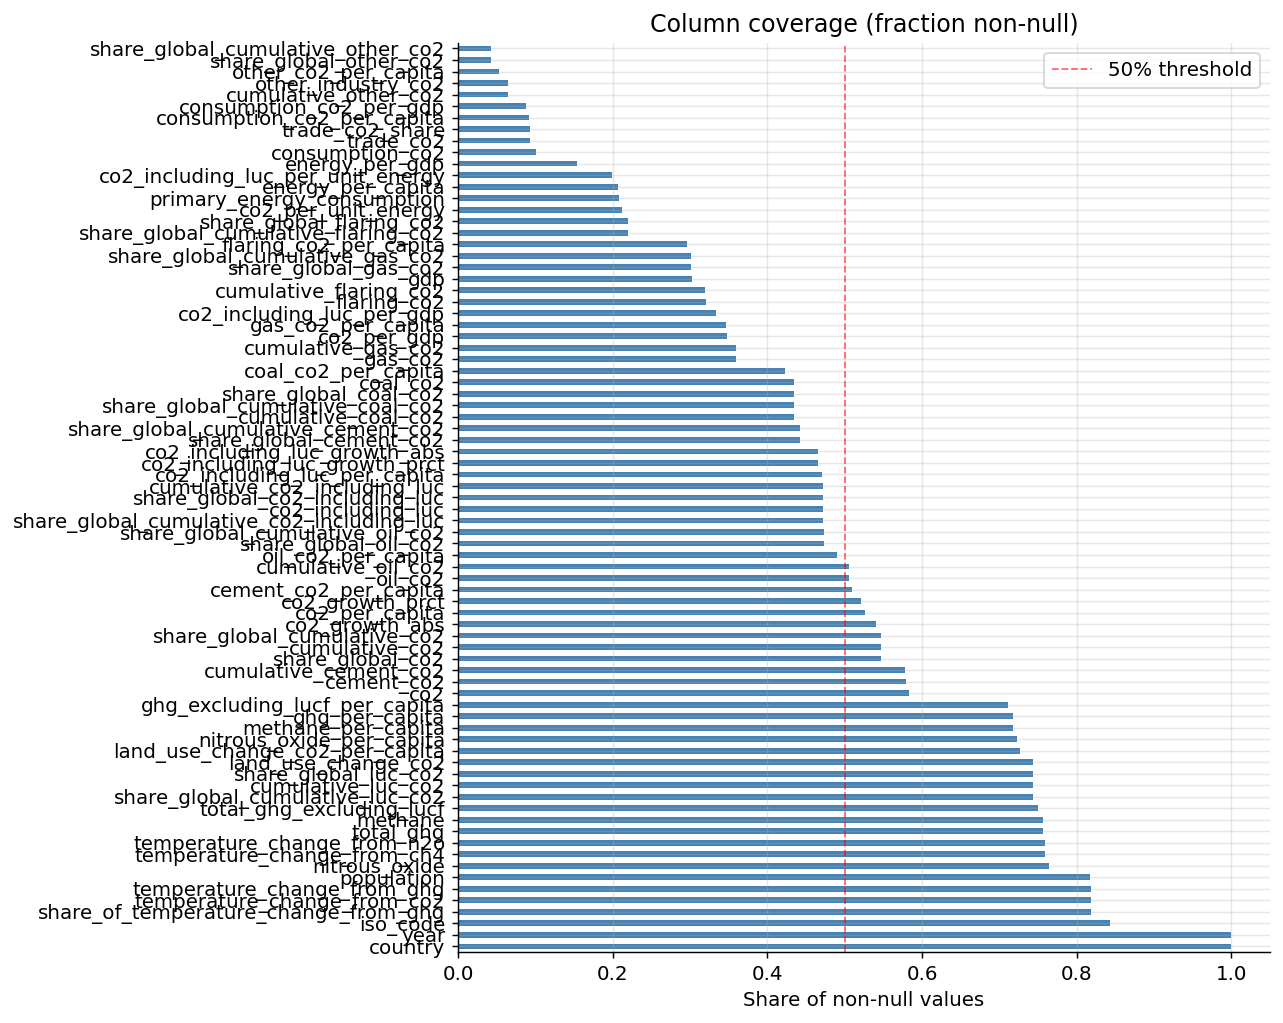

In [18]:
# Coverage: how many values per column?
coverage = df.notna().mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 8))
coverage.plot.barh(ax=ax, color="steelblue", edgecolor="none")
ax.set_xlabel("Share of non-null values")
ax.set_title("Column coverage (fraction non-null)")
ax.axvline(0.5, color="red", lw=1, ls="--", alpha=0.6, label="50% threshold")
ax.legend()
plt.tight_layout()
plt.show()

In [19]:
df.describe(include="number").T[["count", "mean", "min", "max"]].round(2)

,count,mean,min,max
year,50411.0,1.920350e+03,1750.00,2.024000e+03
population,41167.0,6.017453e+07,215.00,8.161973e+09
gdp,15251.0,3.300495e+11,49980000.00,1.301126e+14
cement_co2,29173.0,7.890000e+00,0.00,1.666880e+03
cement_co2_per_capita,25648.0,6.000000e-02,0.00,2.480000e+00
...,...,...,...,...
temperature_change_from_n2o,38280.0,0.000000e+00,0.00,8.000000e-02
total_ghg,38150.0,4.908000e+02,-19.73,5.443340e+04
total_ghg_excluding_lucf,37813.0,3.105200e+02,0.00,4.371478e+04
trade_co2,4712.0,-6.990000e+00,-2177.81,1.768850e+03


## 2. Global CO₂ totals over time
The dataset includes aggregate rows for `"World"` — we use those directly.

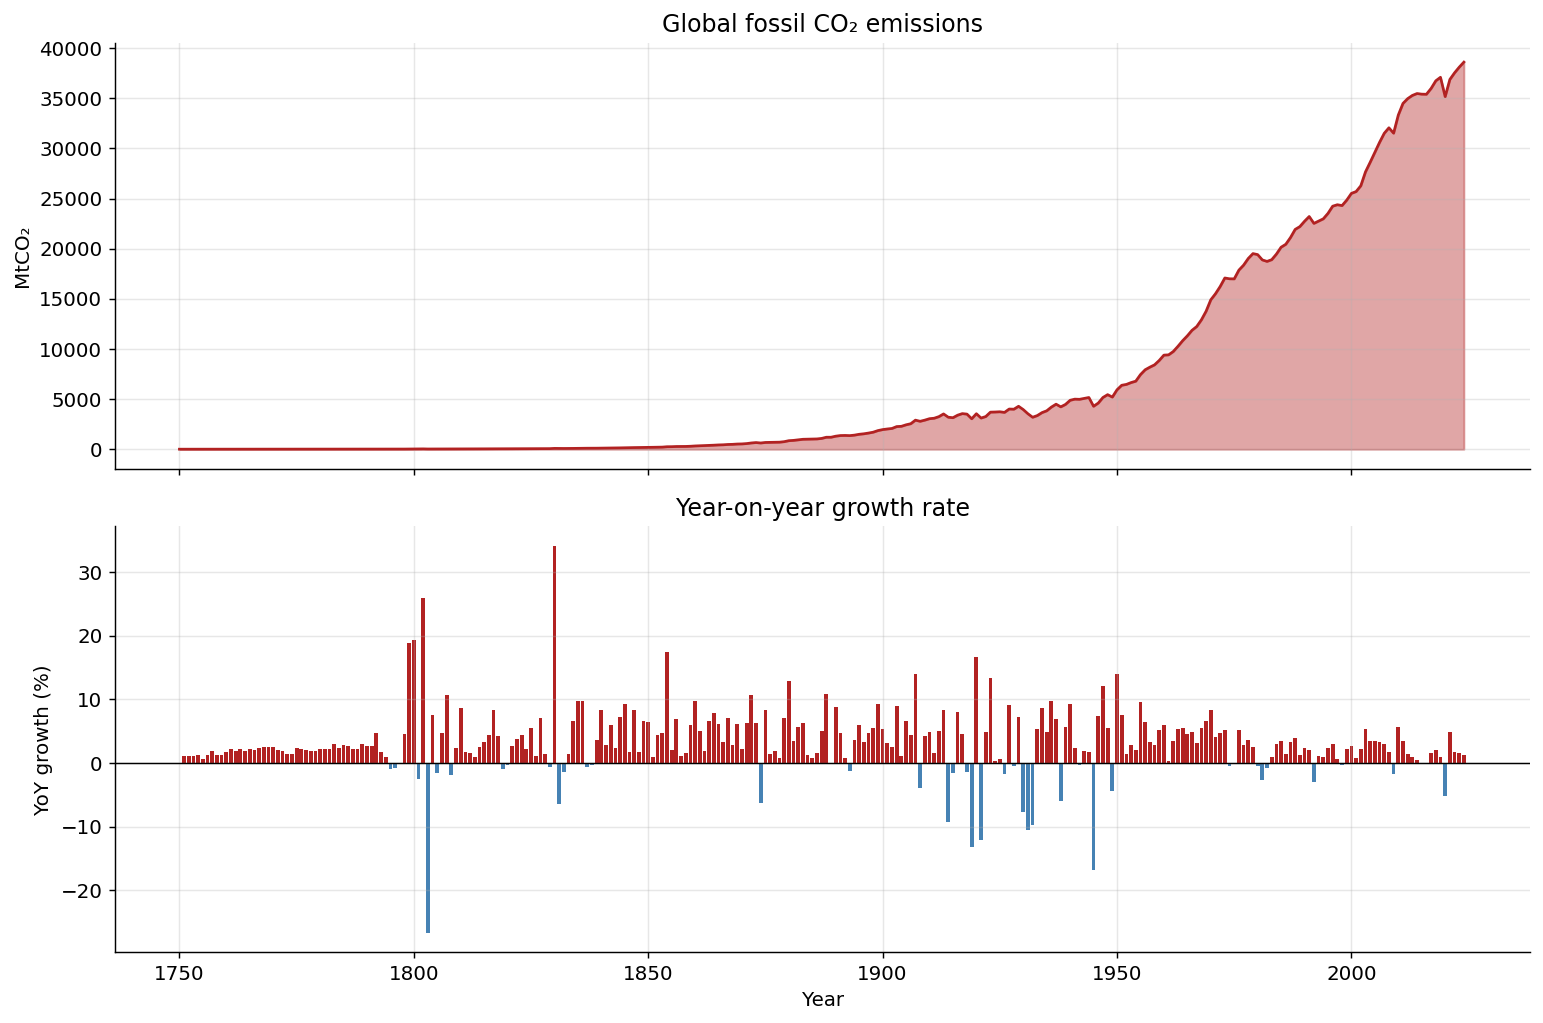

In [20]:
world = df[df["country"] == "World"].copy()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Total CO2
axes[0].fill_between(world["year"], world["co2"], alpha=0.4, color="firebrick")
axes[0].plot(world["year"], world["co2"], color="firebrick", lw=1.5)
axes[0].set_ylabel("MtCO₂")
axes[0].set_title("Global fossil CO₂ emissions")

# YoY growth %
axes[1].bar(world["year"], world["co2_growth_prct"], color=world["co2_growth_prct"].apply(
    lambda x: "firebrick" if x >= 0 else "steelblue"), edgecolor="none", width=0.8)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_ylabel("YoY growth (%)")
axes[1].set_title("Year-on-year growth rate")
axes[1].set_xlabel("Year")

plt.tight_layout()
plt.show()

## 3. Top emitters (most recent year)

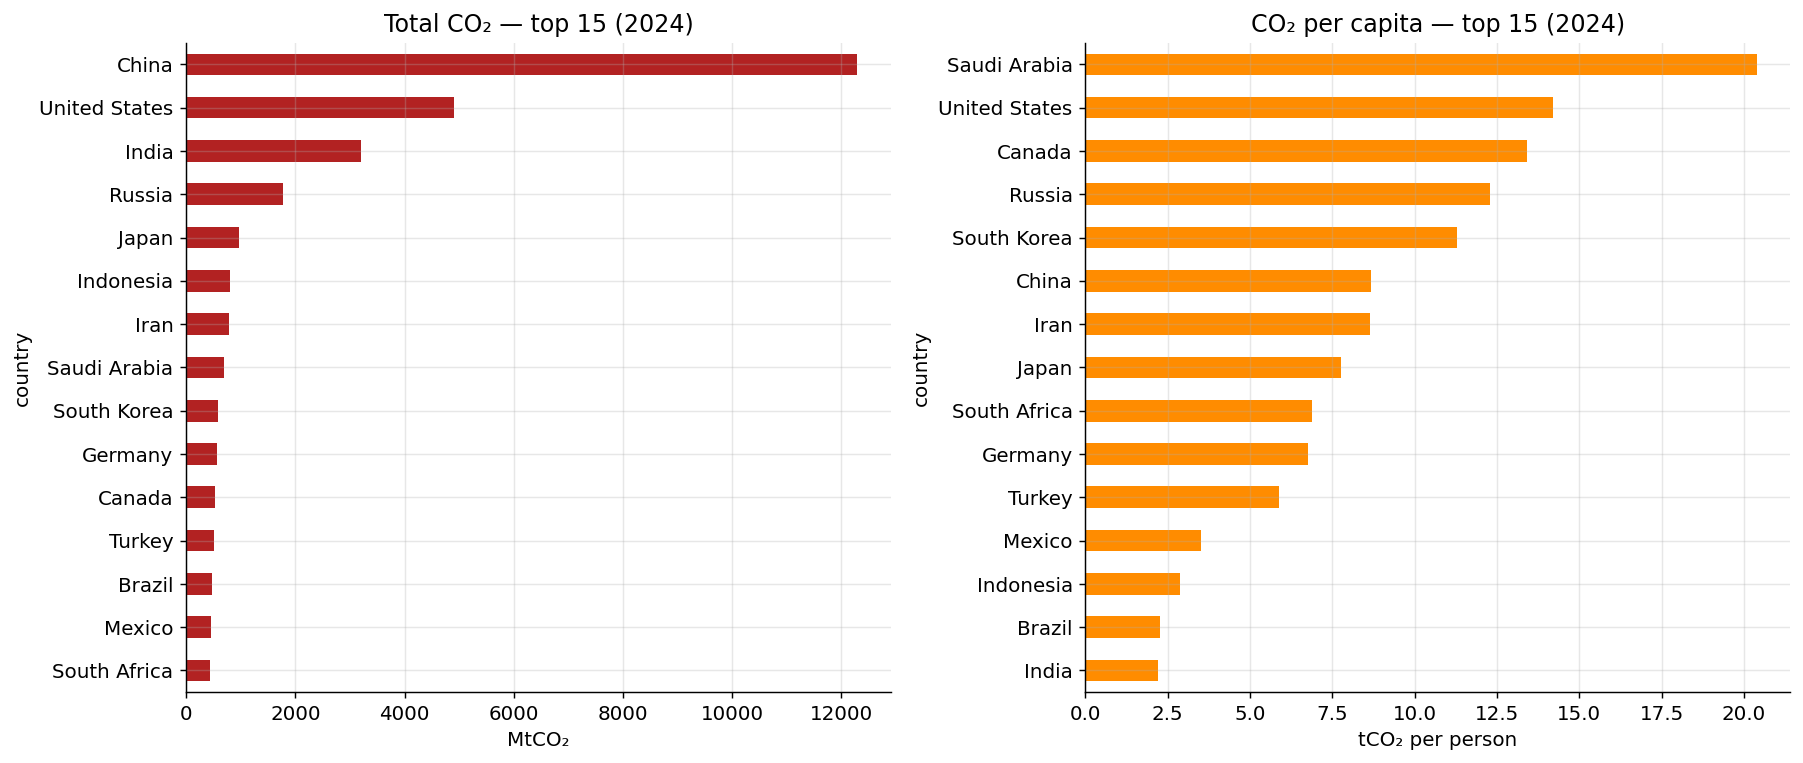

,country,co2,co2_per_capita,share_global_co2
9933,China,12289.04,8.66,31.84
48007,United States,4904.12,14.20,12.70
21762,India,3193.48,2.20,8.27
38314,Russia,1780.52,12.30,4.61
23812,Japan,961.87,7.77,2.49
21937,Indonesia,812.22,2.86,2.10
22662,Iran,792.63,8.66,2.05
40289,Saudi Arabia,692.13,20.38,1.79
43038,South Korea,583.68,11.29,1.51
18319,Germany,572.32,6.77,1.48


In [21]:
# Exclude aggregates (no iso_code = continent/income groups/World)
countries_only = df[df["iso_code"].notna() & (df["iso_code"] != "OWID_WRL")]

latest_year = countries_only["year"].max()
latest = countries_only[countries_only["year"] == latest_year].copy()

top15 = latest.nlargest(15, "co2")[["country", "co2", "co2_per_capita", "share_global_co2"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Total emissions
top15.set_index("country")["co2"].sort_values().plot.barh(ax=axes[0], color="firebrick", edgecolor="none")
axes[0].set_xlabel("MtCO₂")
axes[0].set_title(f"Total CO₂ — top 15 ({latest_year})")

# Per capita
top15.set_index("country")["co2_per_capita"].sort_values().plot.barh(ax=axes[1], color="darkorange", edgecolor="none")
axes[1].set_xlabel("tCO₂ per person")
axes[1].set_title(f"CO₂ per capita — top 15 ({latest_year})")

plt.tight_layout()
plt.show()
top15.round(2)

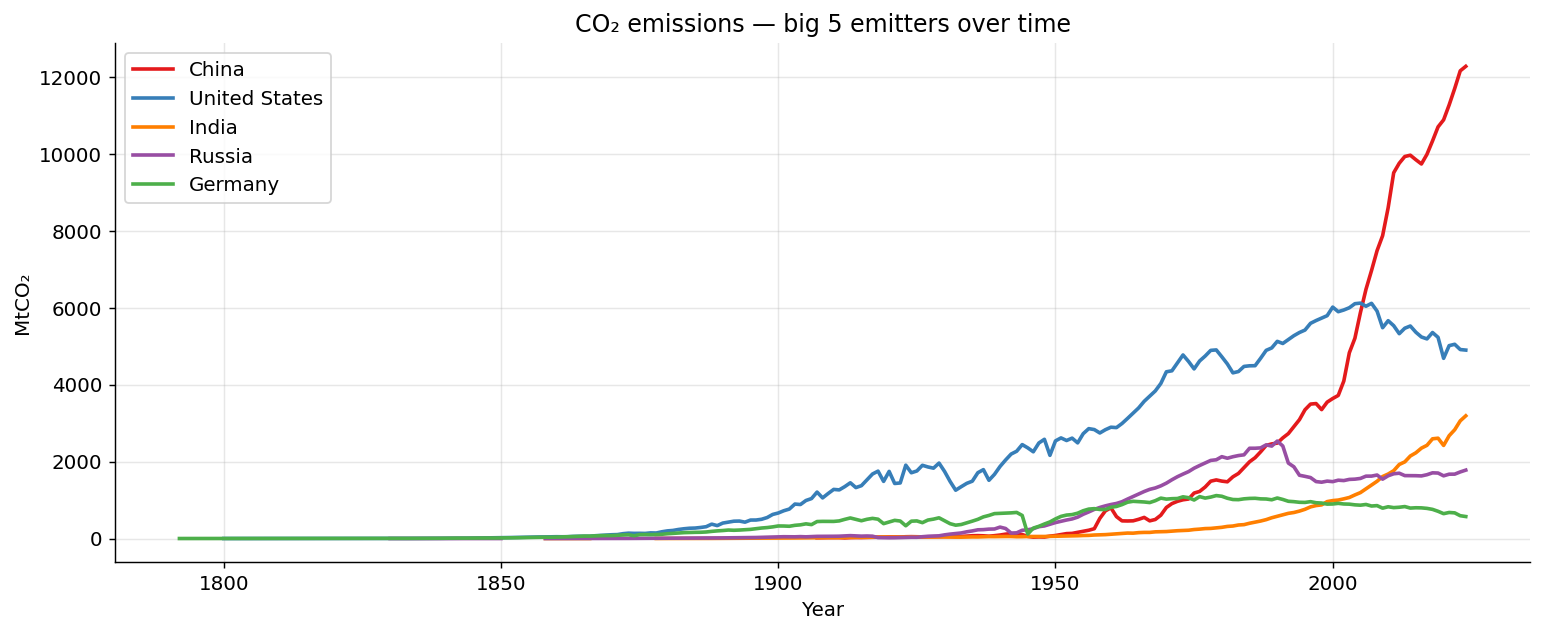

In [22]:
# Historical trajectories for the big 5
big5 = ["China", "United States", "India", "Russia", "Germany"]
palette = ["#e41a1c", "#377eb8", "#ff7f00", "#984ea3", "#4daf4a"]

fig, ax = plt.subplots(figsize=(12, 5))
for country, color in zip(big5, palette):
    sub = countries_only[countries_only["country"] == country]
    ax.plot(sub["year"], sub["co2"], label=country, color=color, lw=2)

ax.set_xlabel("Year")
ax.set_ylabel("MtCO₂")
ax.set_title("CO₂ emissions — big 5 emitters over time")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Emissions by source
Sources: coal, oil, gas, cement, flaring, land-use change (LUC).

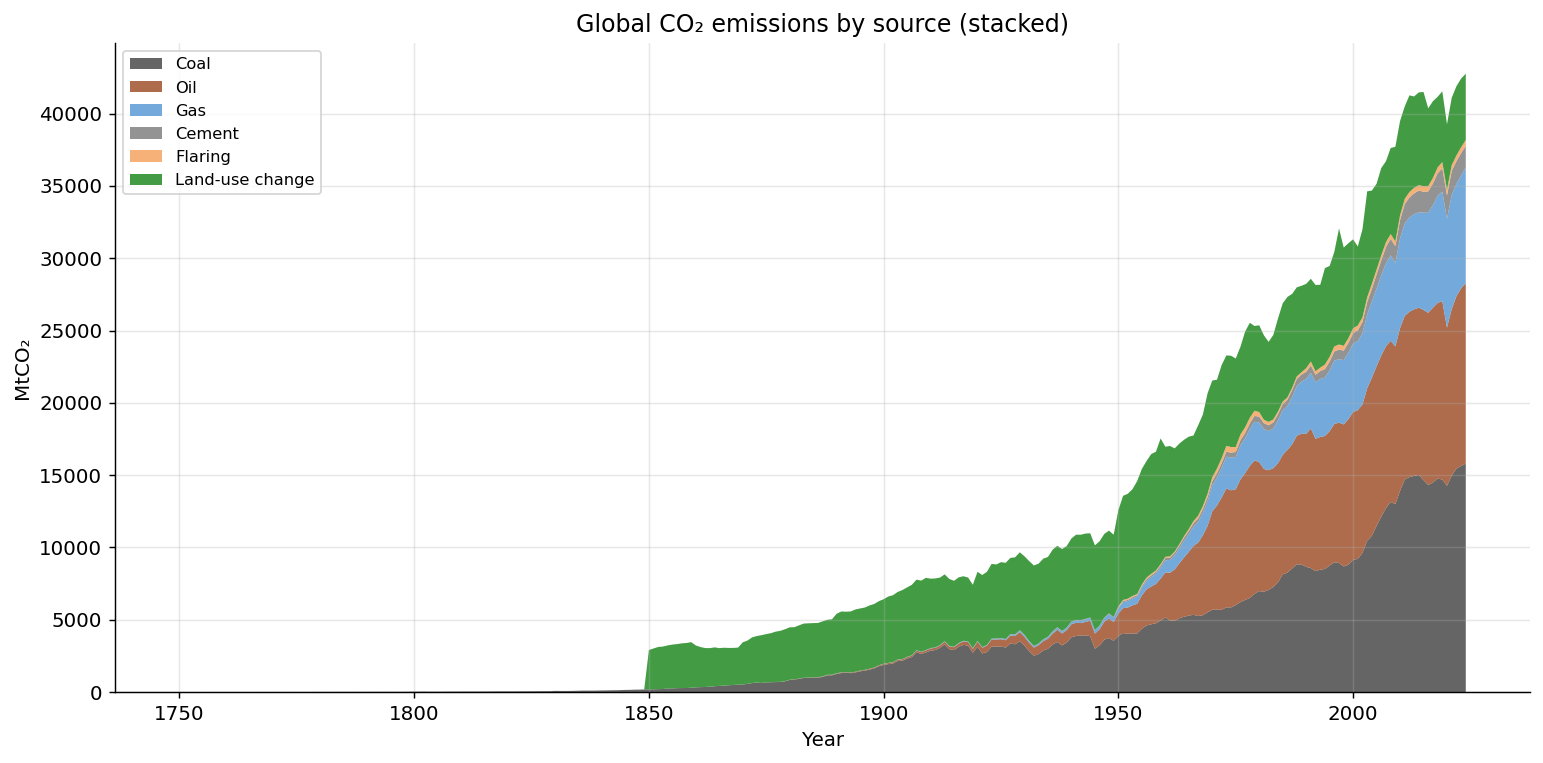

In [23]:
sources = ["coal_co2", "oil_co2", "gas_co2", "cement_co2", "flaring_co2", "land_use_change_co2"]
source_labels = ["Coal", "Oil", "Gas", "Cement", "Flaring", "Land-use change"]
source_colors = ["#4a4a4a", "#a0522d", "#5b9bd5", "#808080", "#f4a460", "#228b22"]

world_src = world[["year"] + sources].dropna(subset=["coal_co2"])

fig, ax = plt.subplots(figsize=(12, 6))
ax.stackplot(
    world_src["year"],
    [world_src[s].clip(lower=0).fillna(0) for s in sources],
    labels=source_labels,
    colors=source_colors,
    alpha=0.85,
)
ax.set_xlabel("Year")
ax.set_ylabel("MtCO₂")
ax.set_title("Global CO₂ emissions by source (stacked)")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

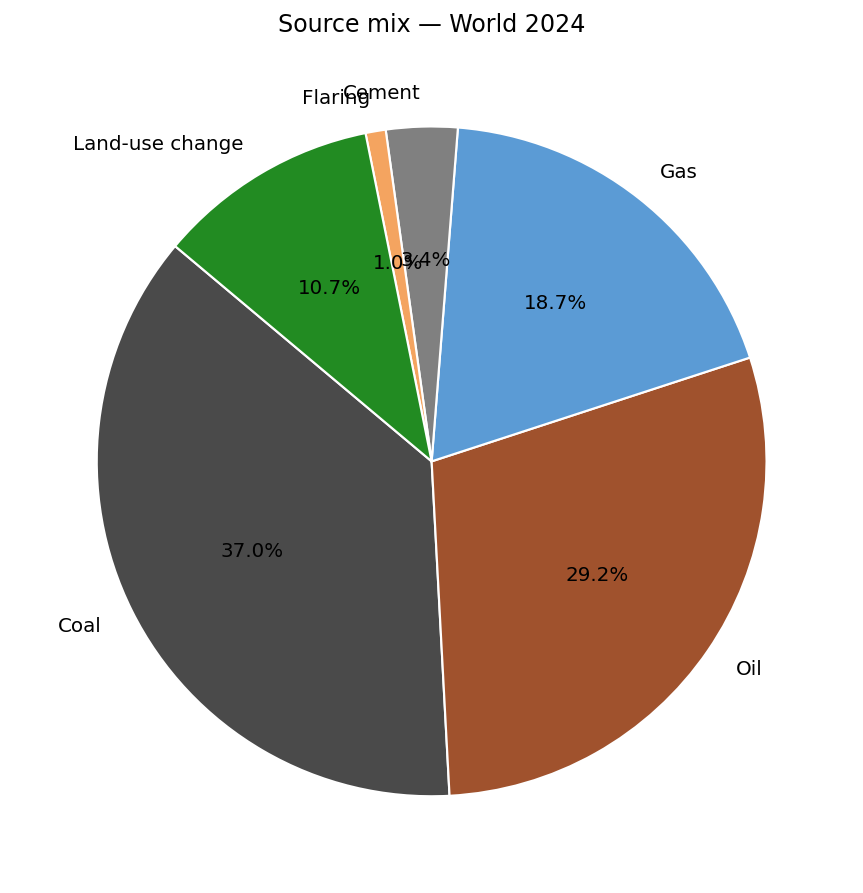

In [24]:
# Source mix for latest year — pie chart
world_latest = world[world["year"] == world["year"].max()].iloc[0]
src_vals = {lbl: max(world_latest[col], 0) for col, lbl in zip(sources, source_labels) if not np.isnan(world_latest[col])}

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    src_vals.values(),
    labels=src_vals.keys(),
    colors=source_colors[:len(src_vals)],
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops=dict(edgecolor="white", linewidth=1.2),
)
ax.set_title(f"Source mix — World {int(world_latest['year'])}")
plt.tight_layout()
plt.show()

## 5. Per-capita & intensity

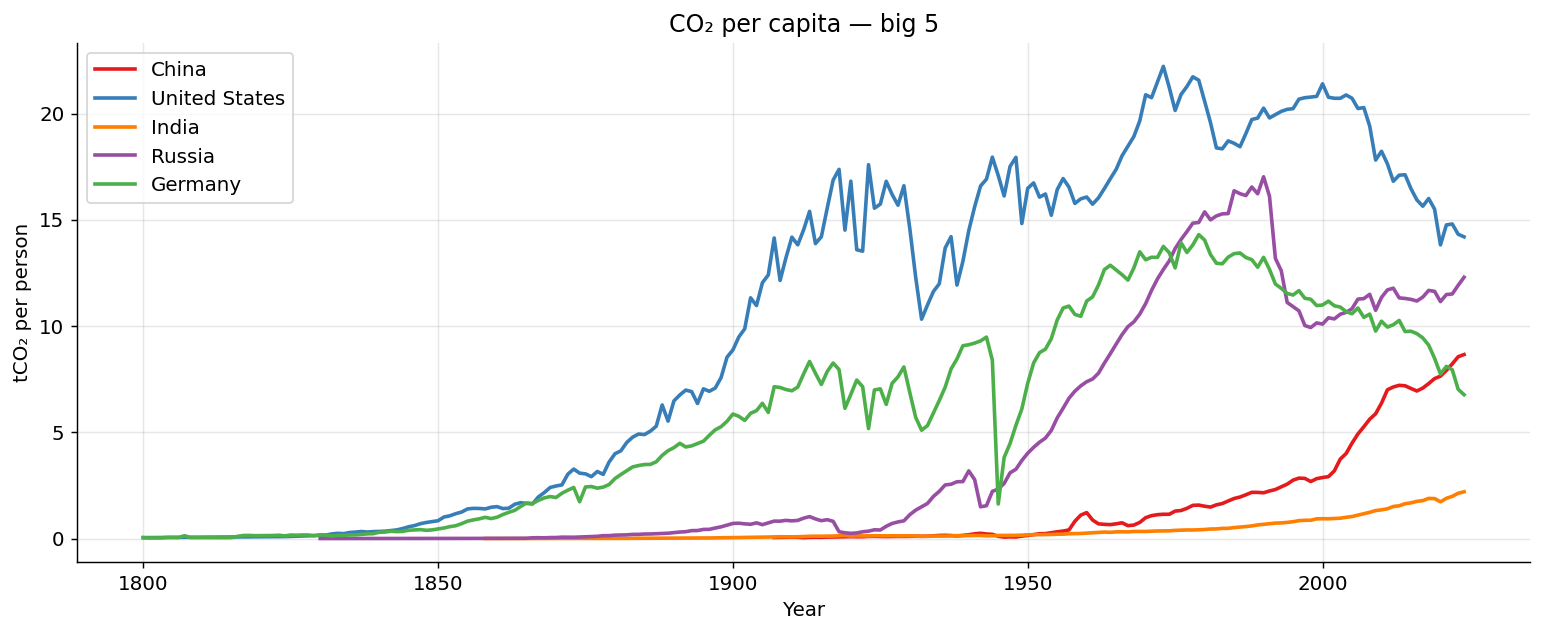

In [25]:
# Per-capita trajectories for big 5
fig, ax = plt.subplots(figsize=(12, 5))
for country, color in zip(big5, palette):
    sub = countries_only[countries_only["country"] == country].dropna(subset=["co2_per_capita"])
    ax.plot(sub["year"], sub["co2_per_capita"], label=country, color=color, lw=2)

ax.set_xlabel("Year")
ax.set_ylabel("tCO₂ per person")
ax.set_title("CO₂ per capita — big 5")
ax.legend()
plt.tight_layout()
plt.show()

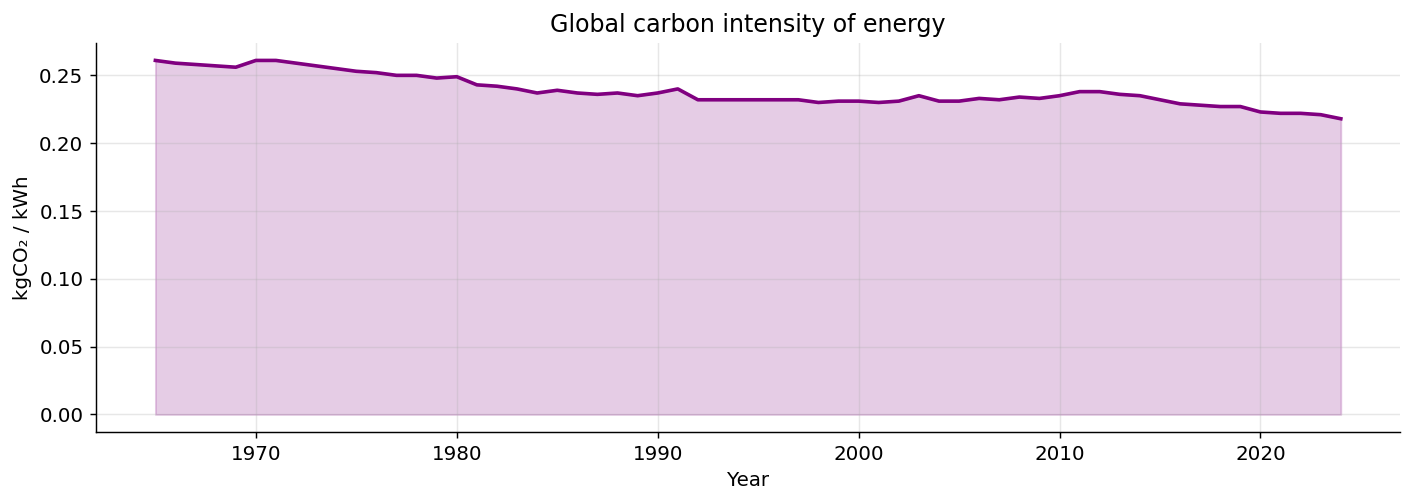

In [26]:
# Carbon intensity (CO2 per unit energy) — global
world_intensity = world.dropna(subset=["co2_per_unit_energy"])

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(world_intensity["year"], world_intensity["co2_per_unit_energy"], color="purple", lw=2)
ax.fill_between(world_intensity["year"], world_intensity["co2_per_unit_energy"], alpha=0.2, color="purple")
ax.set_xlabel("Year")
ax.set_ylabel("kgCO₂ / kWh")
ax.set_title("Global carbon intensity of energy")
plt.tight_layout()
plt.show()

## 6. CO₂ vs GDP
Is wealth correlated with emissions? We look at CO₂ per capita vs GDP per capita (cross-section for latest year with sufficient data).

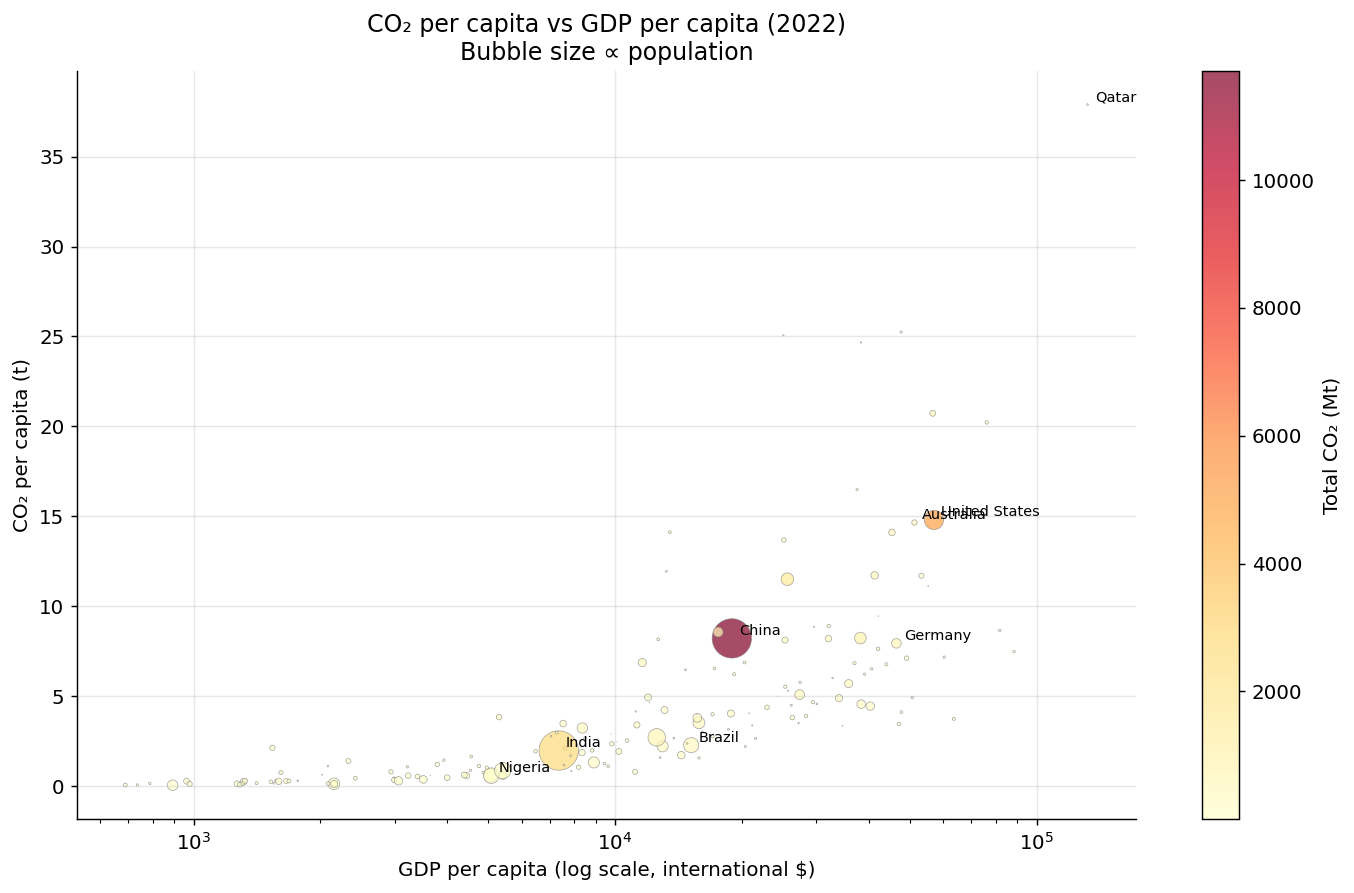

In [27]:
# GDP data lags CO2 data — find the most recent year with sufficient GDP coverage
gdp_latest_year = (
    countries_only.dropna(subset=["gdp"])["year"].max()
)
gdp_latest = countries_only[countries_only["year"] == gdp_latest_year].copy()

scatter_df = gdp_latest.dropna(subset=["co2_per_capita", "gdp", "population", "co2"]).copy()
scatter_df["gdp_per_capita"] = scatter_df["gdp"] / scatter_df["population"]

fig, ax = plt.subplots(figsize=(11, 7))
sc = ax.scatter(
    scatter_df["gdp_per_capita"],
    scatter_df["co2_per_capita"],
    s=scatter_df["population"] / 3e6,   # bubble size = population
    c=scatter_df["co2"],
    cmap="YlOrRd",
    alpha=0.7,
    edgecolors="grey",
    linewidths=0.4,
)
plt.colorbar(sc, ax=ax, label="Total CO₂ (Mt)")

# Label a few notable countries
label_countries = ["China", "United States", "India", "Germany", "Australia", "Qatar", "Nigeria", "Brazil"]
for _, row in scatter_df[scatter_df["country"].isin(label_countries)].iterrows():
    ax.annotate(row["country"], (row["gdp_per_capita"], row["co2_per_capita"]),
                fontsize=8, xytext=(4, 2), textcoords="offset points")

ax.set_xscale("log")
ax.set_xlabel("GDP per capita (log scale, international $)")
ax.set_ylabel("CO₂ per capita (t)")
ax.set_title(f"CO₂ per capita vs GDP per capita ({gdp_latest_year})\nBubble size ∝ population")
plt.tight_layout()
plt.show()

## 7. Cumulative responsibility
Who has emitted the most historically? Cumulative emissions matter for warming because CO₂ persists in the atmosphere for centuries.

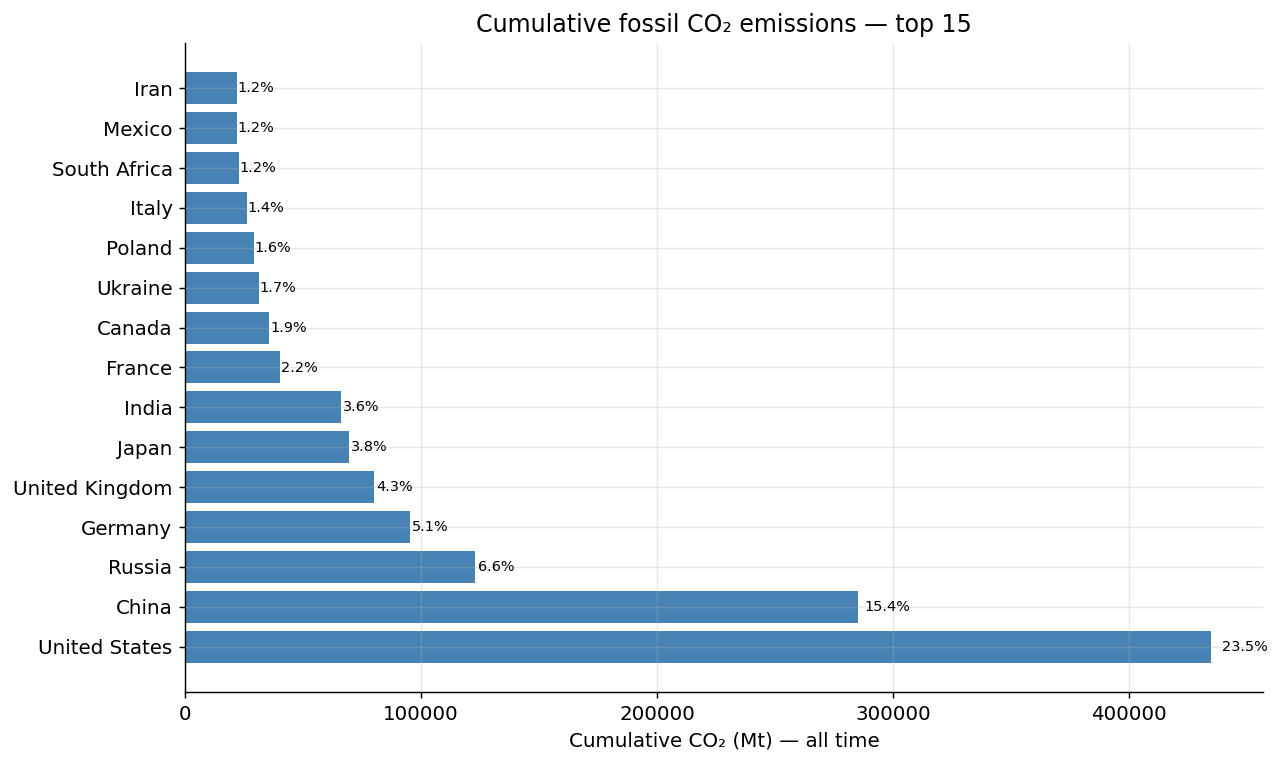

,country,cumulative_co2,share_global_cumulative_co2
48007,United States,434866.6,23.5
9933,China,285087.0,15.4
38314,Russia,122808.2,6.6
18319,Germany,95135.7,5.1
47782,United Kingdom,80079.4,4.3
23812,Japan,69612.3,3.8
21762,India,66072.5,3.6
17383,France,40047.6,2.2
8877,Canada,35644.1,1.9
47232,Ukraine,31236.5,1.7


In [28]:
cum_df = latest.dropna(subset=["cumulative_co2"]).nlargest(15, "cumulative_co2")[
    ["country", "cumulative_co2", "share_global_cumulative_co2"]
]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(cum_df["country"], cum_df["cumulative_co2"], color="steelblue", edgecolor="none")
ax.set_xlabel("Cumulative CO₂ (Mt) — all time")
ax.set_title("Cumulative fossil CO₂ emissions — top 15")

# Add % labels
for bar, pct in zip(bars, cum_df["share_global_cumulative_co2"]):
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}%", va="center", fontsize=8)

plt.tight_layout()
plt.show()
cum_df.round(1)

## 8. Temperature attribution
OWID estimates each country's contribution to global warming from GHG emissions.

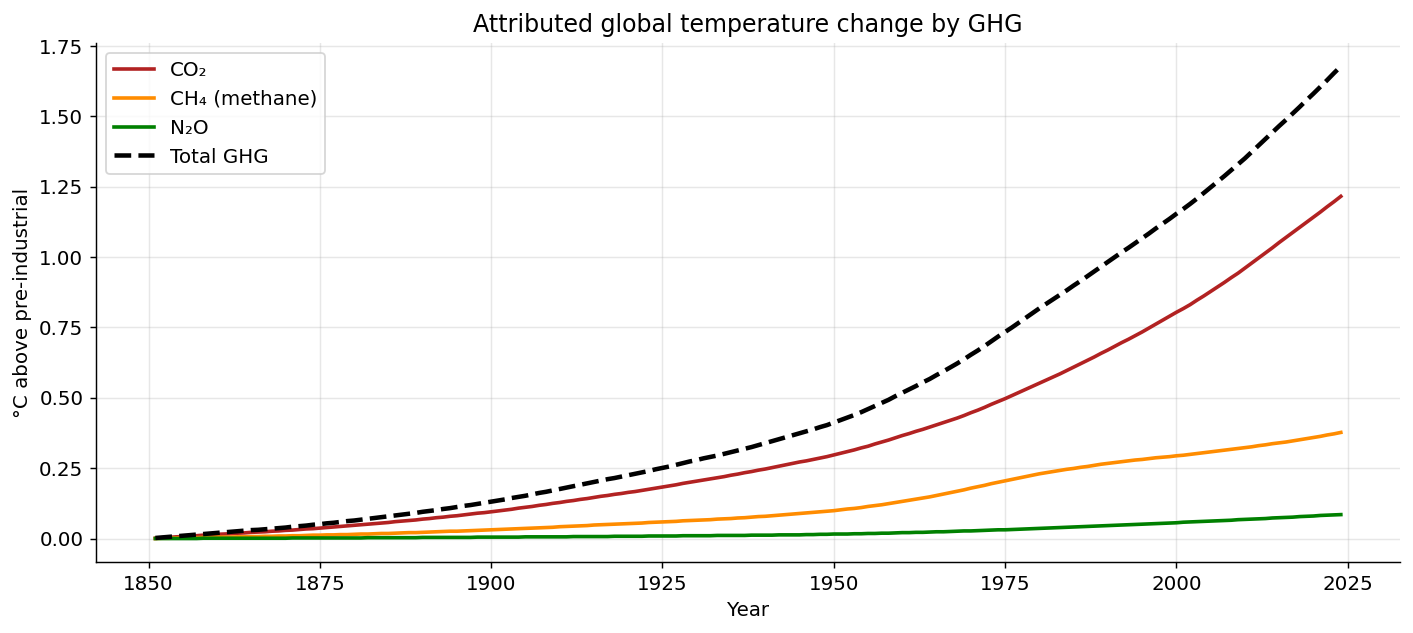

In [29]:
# Global temperature change from GHGs over time
world_temp = world.dropna(subset=["temperature_change_from_ghg"])

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(world_temp["year"], world_temp["temperature_change_from_co2"], label="CO₂", color="firebrick", lw=2)
ax.plot(world_temp["year"], world_temp["temperature_change_from_ch4"], label="CH₄ (methane)", color="darkorange", lw=2)
ax.plot(world_temp["year"], world_temp["temperature_change_from_n2o"], label="N₂O", color="green", lw=2)
ax.plot(world_temp["year"], world_temp["temperature_change_from_ghg"], label="Total GHG", color="black", lw=2.5, ls="--")
ax.set_xlabel("Year")
ax.set_ylabel("°C above pre-industrial")
ax.set_title("Attributed global temperature change by GHG")
ax.legend()
plt.tight_layout()
plt.show()

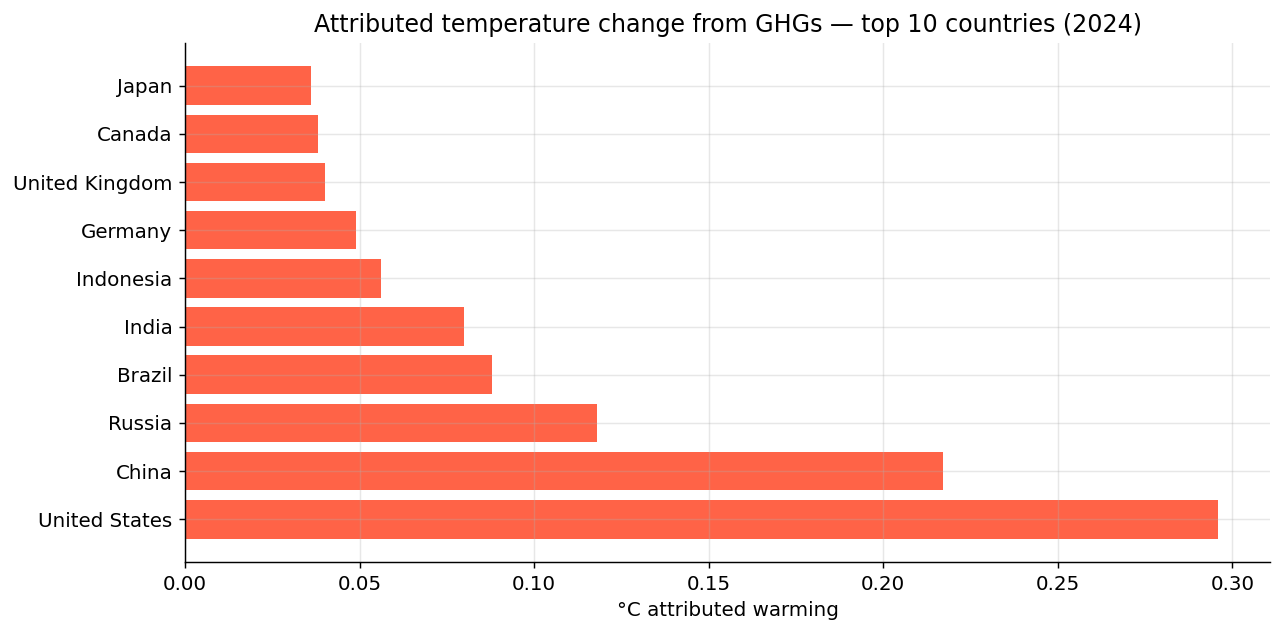

In [30]:
# Top 10 countries by attributed warming
temp_df = latest.dropna(subset=["temperature_change_from_ghg"]).nlargest(10, "temperature_change_from_ghg")

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(temp_df["country"], temp_df["temperature_change_from_ghg"], color="tomato", edgecolor="none")
ax.set_xlabel("°C attributed warming")
ax.set_title(f"Attributed temperature change from GHGs — top 10 countries ({latest_year})")
plt.tight_layout()
plt.show()

---
## Summary of key findings
| Topic | Finding |
|---|---|
| Global trajectory | Emissions rose ~100× since 1850; brief dips in 1929 (Great Depression), 1945, 1973, 2009, 2020 |
| Dominant source | Coal historically, now roughly coal ≈ oil > gas > cement |
| Top emitter today | China (total); Gulf states & Australia (per capita) |
| Historical responsibility | USA alone accounts for ~25% of all cumulative fossil CO₂ |
| CO₂–GDP link | Strong log-linear relationship; outliers are fossil-fuel exporters & very poor countries |
| Carbon intensity | Slow decline since ~1990 as renewables/gas displace coal |
| Warming attribution | CO₂ drives ~65% of attributed warming; methane is the #2 driver |

**Next steps to explore:**
- Consumption-based vs production-based emissions (`consumption_co2`)
- Regional income-group breakdowns using OWID aggregate rows
- Decoupling analysis: countries where GDP grew while emissions fell